In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

In [2]:
DATA_ROOT = Path('../data/FungiTastic')

mask_path = DATA_ROOT / 'FungiTastic-Mini-TrainMasks.parquet'
df_path = DATA_ROOT / 'metadata' / 'FungiTastic-Mini' / 'FungiTastic-Mini-Train.csv'

df = pd.read_csv(df_path)
df["image_path"] = df.filename.apply(
  lambda x: str((DATA_ROOT / 'FungiTastic' / 'train' / '300p' / x).resolve())
)

gt_masks = pd.read_parquet(mask_path)
gt_masks.rename(columns={'file_name': 'filename'}, inplace=True)

df = df.merge(gt_masks, on='filename', how='inner')


In [3]:
print(df.columns.tolist())

['eventDate', 'year', 'month', 'day', 'habitat', 'countryCode', 'scientificName', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'specificEpithet', 'hasCoordinate', 'species', 'iucnRedListCategory', 'substrate', 'latitude', 'longitude', 'coorUncert', 'observationID', 'region', 'district', 'filename', 'category_id', 'metaSubstrate', 'poisonous', 'elevation', 'landcover', 'biogeographicalRegion', 'captions', 'image_path', 'label', 'width', 'height', 'rle']


In [4]:

# print(df.head())
# print(gt_masks.head())
print('---')
print(df[['filename', 'rle', 'width', 'height', 'label']].sample())
print(df.loc[df['filename'] == "0-3036761318.JPG"])
print(df['filename'].agg(['count', 'size', 'nunique'])) # 13803 unique images with fungi

---
               filename                                                rle  \
24457  0-3410052313.JPG  [4141194, 46, 3778, 79, 3749, 99, 3731, 116, 3...   

       width  height label  
24457   3840    5120   cap  
    eventDate  year  month  day             habitat countryCode  \
0  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
1  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
2  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
3  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
4  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   
5  2008-09-01  2008    9.0  1.0  Deciduous woodland          DK   

                       scientificName kingdom         phylum           class  \
0  Russula cyanoxantha (Schaeff.) Fr.   Fungi  Basidiomycota  Agaricomycetes   
1  Russula cyanoxantha (Schaeff.) Fr.   Fungi  Basidiomycota  Agaricomycetes   
2  Russula cyanoxantha (Schaeff.) Fr.   Fungi  Basidiomycota  Agaricomy

image.size=(300, 225)


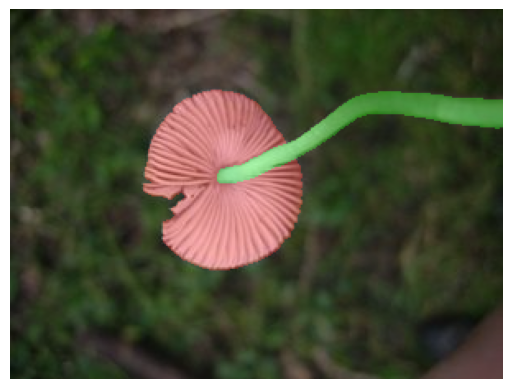

image.size=(300, 169)


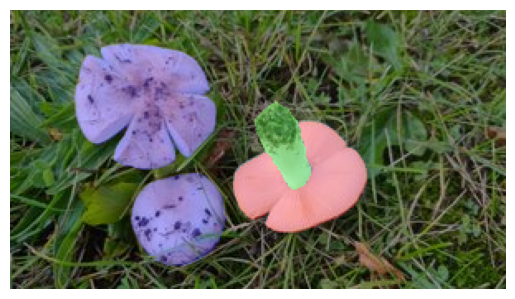

image.size=(300, 184)


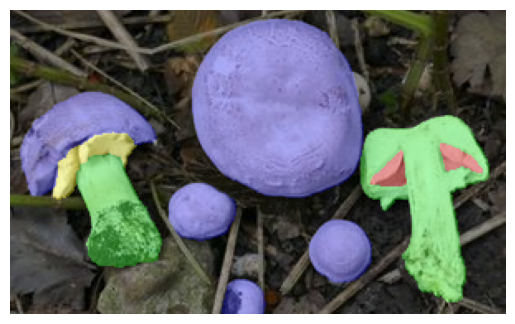

image.size=(300, 300)


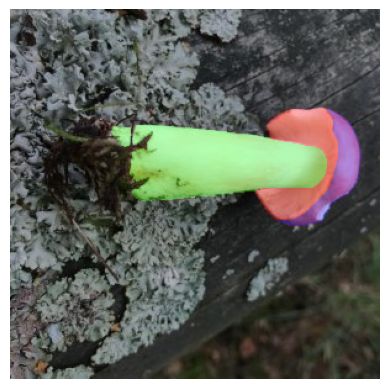

image.size=(300, 400)


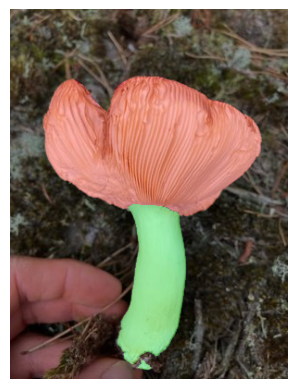

In [5]:
def rle_to_mask(rle_points, height, width):
  mask = np.zeros(height * width, dtype=np.uint8)
  rle_counts = rle_points[:-4]
  current_position = 0
  current_value = 0
  for rle_count in rle_counts:
    mask[current_position:current_position + rle_count] = current_value
    current_value ^= 1
    current_position += rle_count
  mask = mask.reshape((height, width))
  return mask

def visualize_mask(filename):
  rows = df.loc[df['filename'] == filename]

  image_path = rows['image_path'].iloc[0]
  image = Image.open(image_path)

  print(f'{image.size=}')
  
  colors = {
    'gills':         (255, 0, 0),
    'stem':          (0, 255, 0),
    'cap':           (0, 0, 255),
    'ring':          (255, 255, 0),
    'pores':         (255, 0, 255),
    'fruiting_body': (0, 255, 255)
  }
  # colors = {
  #     0: (255, 0, 0),    # gills - red
  #     1: (0, 255, 0),    # stem - green
  #     2: (0, 0, 255),    # cap - blue
  #     3: (255, 255, 0),  # ring - yellow
  #     4: (255, 0, 255),  # pores - magenta
  #     5: (0, 255, 255)   # fruiting_body - cyan
  # }

  width, height = image.size
  overlay = np.zeros((height, width, 3), dtype=np.uint8)
  for row in rows[['rle', 'label', 'width', 'height']].itertuples():
    mask = rle_to_mask(row.rle, row.height, row.width)
    mask = cv2.resize(mask.astype(np.uint8), image.size, interpolation=cv2.INTER_NEAREST).astype(bool)
    if row.label == 'fruiting_body':
      continue
    # print(rle, label, width, height)
    # print(row.label, row.rle)
    # plt.imshow(mask)
    # plt.show()
    # plt.imshow(mask, cmap=color[row.label])
    # plt.show()
    # if mask_sum is None:
    #   mask_sum = mask
    # else:
    overlay[mask] = colors[row.label]
    # print(mask_sum.shape, mask.shape)
    # mask_sum |= (2**attribute[row.label]) * mask
  
  image_np = np.array(image)
  blended = cv2.addWeighted(image_np, 0.7, overlay, 0.3, 0)

  plt.imshow(blended)
  plt.axis('off')
  plt.show()

# print(df.loc[df['filename'] == "0-3036761318.JPG"])


# visualize_mask("0-3036761318.JPG")
# visualize_mask("0-3419915381.JPG")
for i in range(5):
  filename = df['filename'].sample().iloc[0]
  visualize_mask(filename)

In [1]:
from pathlib import Path
from typing import Callable

import lightning as L
import torch

from torch.utils.data import DataLoader, Dataset, random_split

import cv2
import numpy as np
import pandas as pd
from torchvision.io import read_image, ImageReadMode

class FungiTasticDataset(Dataset):

  LABEL_TO_ID = {
    "cap": 1,
    "stem": 2,
    "gills": 3,
    "pores": 4,
    "ring": 5,
    "ridges": 6,
    "teeth": 7,
    "unknown underside": 8
  }

  IGNORE_LABELS = {
    "fruiting_body",
    "microscopic"
  }

  def __init__(self, data_root: Path, split: str, transform=None):
    self.data_root = Path(data_root)
    self.split = split
    self.transform = transform

    image_root = self.data_root / "FungiTastic-Mini" / split / "300p"

    mask_name = {
      "train": "Train",
      "val" : "Validation",
      "test": "Test"
    }[split]

    meta_name = {
      "train": "Train",
      "val": "Val",
      "test": "Test"
    }[split]

    meta_path = (
      self.data_root
      / "metadata"
      / "FungiTastic-Mini"
      / f"FungiTastic-Mini-{meta_name}.csv"
    )

    mask_path = self.data_root / f"FungiTastic-Mini-{mask_name}Masks.parquet"

    meta = pd.read_csv(meta_path, usecols=["filename"])
    masks = pd.read_parquet(
      mask_path,
      columns=["file_name", "label", "width", "height", "rle"]
    ).rename(columns={"file_name": "filename"})

    valid_filenames = set(meta["filename"])
    masks = masks[masks["filename"].isin(valid_filenames)].copy()
    
    masks = masks[~masks["label"].isin(self.IGNORE_LABELS)].copy()
    masks["label_id"] = masks["label"].map(self.LABEL_TO_ID)

    unknown_labels = masks.loc[masks["label_id"].isna(), "label"].unique()
    # print(f'{unknown_labels=}')
    assert len(unknown_labels) == 0

    masks["label_id"] = masks["label_id"].astype(np.uint8)

    masks = masks.sort_values("filename", kind="stable").reset_index(drop=True)

    filenames = masks["filename"].to_numpy()

    starts = np.flatnonzero(
      np.r_[True, filenames[1:] != filenames[:-1]]
    )

    self.part_offsets = np.r_[starts, len(masks)].astype(np.int64)

    self.filenames = filenames[starts].tolist()
    self.image_paths = [
      str(image_root / filename)
      for filename in self.filenames
    ]

    self.part_rles = masks["rle"].to_numpy(dtype=object)
    self.part_label_ids = masks["label_id"].to_numpy(np.uint8)
    self.part_widths = masks["width"].to_numpy(np.int32)
    self.part_heights = masks["height"].to_numpy(np.int32)

    del meta
    del masks

  def __len__(self) -> int:
    return len(self.filenames)

  def __getitem__(self, idx: int):
    image = read_image(self.image_paths[idx], mode=ImageReadMode.RGB)

    start = self.part_offsets[idx]
    end = self.part_offsets[idx + 1]

    mask = self._build_semantic_mask(start, end)

    image_h, image_w = image.shape[-2:]
    mask = cv2.resize(
      mask,
      (image_w, image_h),
      interpolation=cv2.INTER_NEAREST
    )

    mask = torch.from_numpy(mask).long()

    image, mask = self._pad_crop_300(image, mask)

    image = image.float() / 255.0

    if self.transform is not None:
      image, mask = self.transform(image, mask)
    
    return image, mask

  def _build_semantic_mask(self, start: int, end: int) -> np.ndarray:
    height = int(self.part_heights[start])
    width = int(self.part_widths[start])

    semantic = np.zeros((height, width), dtype=np.uint8)

    for part_idx in range(start, end):
      part_mask = self._rle_to_mask(
        self.part_rles[part_idx],
        int(self.part_heights[part_idx]),
        int(self.part_widths[part_idx])
      )

      label_id = self.part_label_ids[part_idx]
      semantic[part_mask.astype(bool)] = label_id
    
    return semantic

  @staticmethod
  def _rle_to_mask(rle_points, height: int, width: int) -> np.ndarray:
    mask = np.zeros(height * width, dtype=np.uint8)

    position = 0
    value = 0
    for count in rle_points[:-4]:
      if value == 1:
        mask[position:position + count] = 1
      
      position += count
      value ^= 1
    
    return mask.reshape(height, width)
  
  @staticmethod
  def _pad_crop_300(image: torch.Tensor, mask: torch.Tensor):
    target = 300
    _, h, w = image.shape

    pad_h = max(0, target - h)
    pad_w = max(0, target - w)

    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    image = torch.nn.functional.pad(
      image,
      (left, right, top, bottom),
      value=0
    )

    mask = torch.nn.functional.pad(
      mask,
      (left, right, top, bottom),
      value=0
    )

    _, h, w = image.shape

    top = max(0, (h - target) // 2)
    left = max(0, (w - target) // 2)

    image = image[:, top:top + target, left:left + target]
    mask = mask[top:top + target, left:left + target]

    return image, mask

In [4]:
DATA_ROOT = Path('../data/FungiTastic')
dataset = FungiTasticDataset(DATA_ROOT, 'val')

# print(dataset[0])

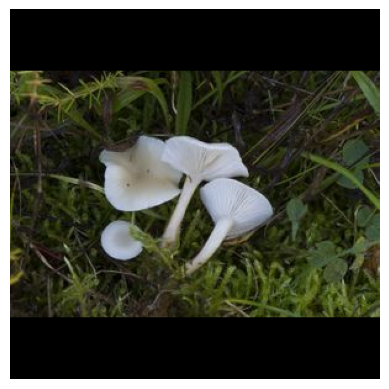

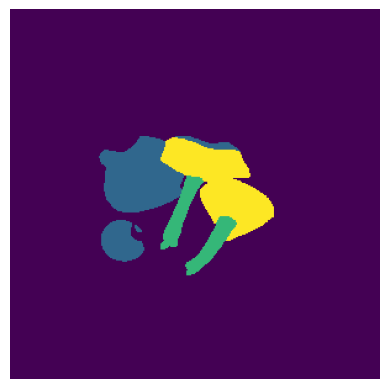

8672


In [5]:
import matplotlib.pyplot as plt

img, mask = dataset[3251]
img = img.permute(1, 2, 0)

plt.imshow(img)
plt.axis('off')
plt.show()

plt.imshow(mask)
plt.axis('off')
plt.show()

print(len(dataset))